# Cliff Walking: On-Policy Sarsa

## Installation and Setup

In [1]:
# uncomment if needed
# %pip install "gym-classics2 @ git+https://github.com/mhahsler/gym-classics2.git"

In [2]:
import numpy as np
np.set_printoptions(precision=2)

SEED = 42
rng = np.random.default_rng(SEED)

In [3]:
import gymnasium as gym
import gym_classics2
gym_classics2.register('gymnasium')

from gym_classics2.animation import gridworld_animate                               
from gym_classics2.algorithms.policy import random_policy

## Cliff Walking

Example from Sutton/Barto Chapter 6.

![Clif Walking problem description](https://raw.githubusercontent.com/mhahsler/Introduction_to_Reinforcement_Learning/refs/heads/main/figures/RL-intro_Cliffwalking.png)

Cliff Walking is a standard undiscounted,
episodic task, with start
and goal states, and the usual actions
causing movement up, down,
right, and left. Reward is −1 on all
transitions except those into the region
marked “The Cliff.” Stepping
into this region incurs a reward of
−100 and sends the agent instantly
back to the start.

In [4]:
from gym_classics2.envs.abstract.gridworld import Gridworld

class CliffWalk(Gridworld):
    layout = """
|            |
|            |
|            |
|S          G|
"""

    def __init__(self, tabular = True):
        self._cliff = frozenset((x, 0) for x in range(1, 11))
        super().__init__(CliffWalk.layout, tabular = tabular)
    
    # cliff is unreachable. Leads to the start state    
    def _next_state(self, state, action):
        state, _ = super()._next_state(state, action)
        if (state in self._cliff):
            state = self._starts[0]
        return state, 1.0

    def _reward(self, state, action, next_state):
        # actions from goal states always have a reward of 0
        if state in self._goals: 
            return 0.0
        
        # handle stepping on the cliff 
        n_state, _ = super()._next_state(state, action)
        if n_state in self._cliff: 
            return -100.0
         
        return -1.0

    def _done(self, state, action, next_state):
        return next_state in self._goals

gym.register('CliffWalk-v1', entry_point=CliffWalk)

/home/mhahsler/miniconda3/envs/reinforcement-learning/lib/python3.12/site-packages/gymnasium/envs/registration.py:637: UserWarning: WARN: Overriding environment CliffWalk-v1 already in registry.
  logger.warn(f"Overriding environment {new_spec.id} already in registry.")



Note: The patched version of the `gym_classic` also contains this environment as 'CliffWalk-v1'.

In [5]:
gym_env = gym.make('CliffWalk-v1', tabular = True)
env = gym_env.unwrapped
env.reset(seed=SEED)

(0, {})

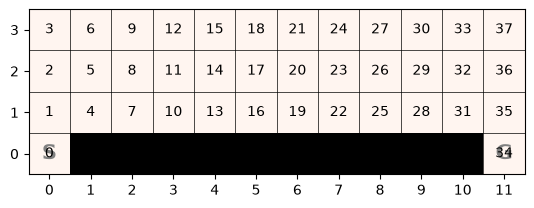

In [6]:
env.image()

## Optimal Policy

This environment has model access, so we can for comparison use value iteration to find the optimal policy.

Value Iteration: 0it [00:00, ?it/s]

Value Iteration: 15it [00:00, 300.18it/s]


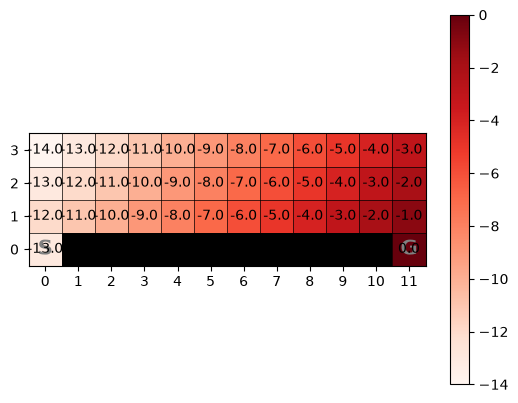

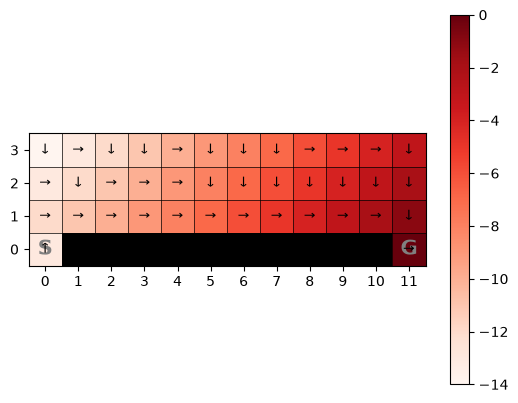

In [7]:
from gym_classics2.algorithms.dynamic_programming import value_iteration
from gym_classics2.algorithms.policy import greedy_policy

V_star = value_iteration(env, discount=1)
policy_star = greedy_policy(V_star, env, discount=1, rng=rng)

env.image(V_star, labels=True)
env.image(V_star, policy=policy_star)

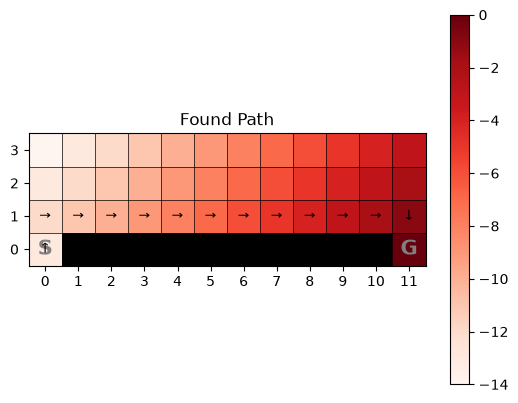

In [8]:
from gym_classics2.algorithms.monte_carlo_methods import sample_episode

path = sample_episode(env, policy=policy_star, max_len=100)
env.image(V=V_star, policy=policy_star, episode=path, title='Found Path')

The optimal policy leads along the cliff.

**Note:** Actions in the goal state are artifacts and do not matter!

## On-Policy: Sarsa

![Algorithm: Sarsa](https://raw.githubusercontent.com/mhahsler/Introduction_to_Reinforcement_Learning/refs/heads/main/figures/RL-Intro_Alg_Sarsa_TD.png)

In [9]:
from tqdm import tqdm

# np.argmax does not break ties randomly
def random_argmax(x, rng):
    return rng.choice(np.where(x == np.max(x))[0])


def Sarsa0(env, discount, alpha, epsilon, n=100, verbose=False, rng=None):
    rng = np.random.default_rng(rng)
    Q = np.zeros((len(env.states()), len(env.actions())))
    
    for i in tqdm(range(n), desc="SARSA", disable=verbose):
        s, r = env.reset()
         
        
        if verbose:
            print ("--- New Episode ---") 
          
        if rng.random() > epsilon:
            a = random_argmax(Q[s,:], rng)
        else:
            a = rng.integers(env.action_space.n)  
          
        done = False
        while not done:            
            sp, r, done, _, _ = env.step(a)
        
            if rng.random() > epsilon:
                ap = random_argmax(Q[sp,:], rng)
            else:
                ap = rng.integers(env.action_space.n) 
        
            Q[s,a] = Q[s,a] + alpha * (r + discount * Q[sp,ap] - Q[s,a])
            
            if verbose:
                print("sarsa:", s,a,r,sp,ap, "New Q(s,a):", Q[s,a])
            
            s = sp
            a = ap
          
    return Q

Learn an $\epsilon$-greedy policy (Q-function). TD is not sample efficient, so we need a large $n$.

### Using Different Exploration Levels

#### Epsilon 0.5

In [10]:
Q = Sarsa0(env, discount=1, alpha=.01, epsilon=.5, n=10000, rng=rng)

SARSA:   0%|          | 3/10000 [00:00<13:56, 11.95it/s]

SARSA: 100%|██████████| 10000/10000 [00:08<00:00, 1134.10it/s]


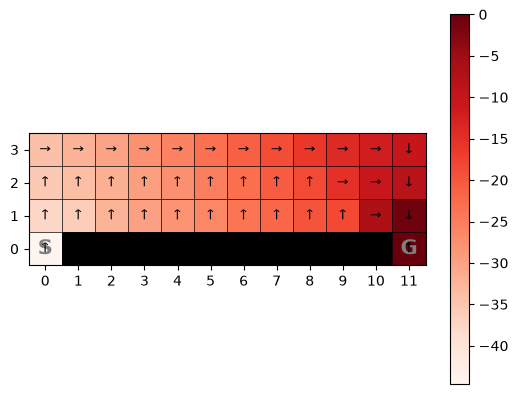

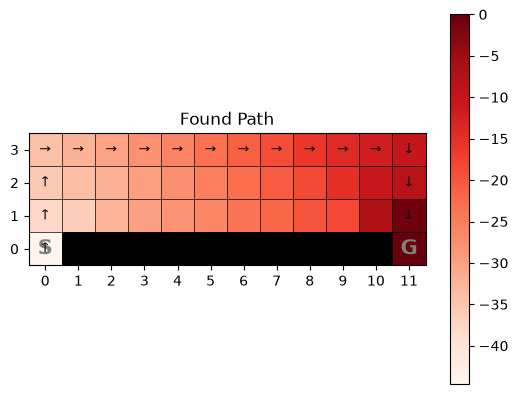

In [11]:
policy = np.argmax(Q, axis=1)
V = np.max(Q, axis = 1)

env.image(V, policy = policy)
path = sample_episode(env, policy=policy)
env.image(V=V, policy=policy, episode=path, title='Found Path')

#### Epsilon 0.1

In [12]:
Q = Sarsa0(env, discount=1, alpha=.01, epsilon=.5, n=10000, rng=rng)

SARSA: 100%|██████████| 10000/10000 [00:08<00:00, 1184.58it/s]


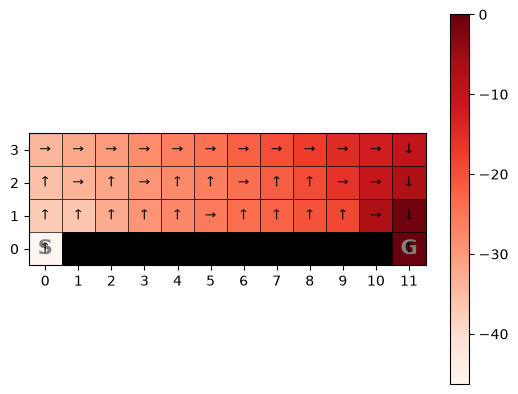

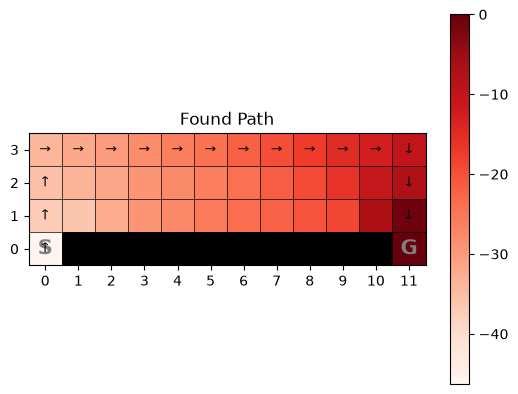

In [13]:
policy = np.argmax(Q, axis=1)
V = np.max(Q, axis = 1)

env.image(V, policy = policy)
path = sample_episode(env, policy=policy)
env.image(V=V, policy=policy, episode=path, title='Found Path')

#### Epsilon 0.01

In [14]:
Q = Sarsa0(env, discount=1, alpha=.01, epsilon=.01, n=10000, rng=rng)

SARSA: 100%|██████████| 10000/10000 [00:05<00:00, 1836.18it/s]


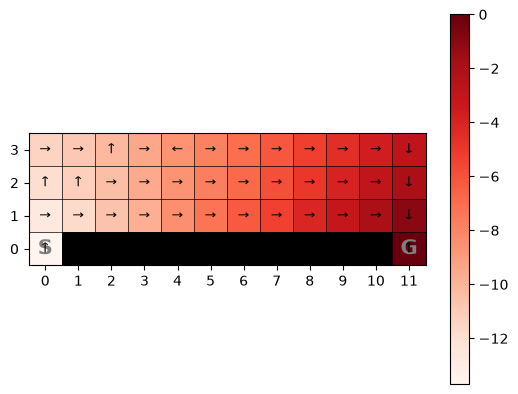

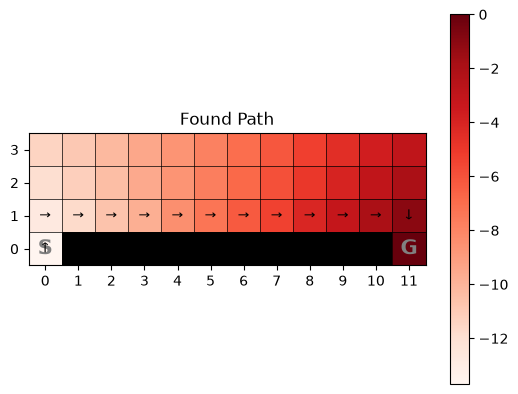

In [15]:
policy = np.argmax(Q, axis=1)
V = np.max(Q, axis = 1)

env.image(V, policy = policy)
path = sample_episode(env, policy=policy)
env.image(V=V, policy=policy, episode=path, title='Found Path')

**Note:** Walking along the cliff is the optimal path in this deterministic grid world. However, since Sarsa is an on-policy method and learns an $\epsilon$-greedy policy, 
walking along the cliff is not a good idea when $\epsilon$ is large! This is why the policy sends us up to row 2 or 3 depending on $\epsilon$.
An $\epsilon$ of 0.01 is small enough to still take the risk.

### Learn With GLIE

We implement a on-policy version of SARSA which converges to the optimal $\epsilon$-soft policy.
We can reduce $\epsilon$ over time to converge to the optimal policy. This is part of GLIE.

In [16]:
class ExponentialDecaySchedule:
    """A schedule that decays exponentially with a given decay_rate.
    Value at time t is max(min_value, initial_value * (decay_rate ** t)).
    """
    def __init__(self, initial_value, min_value, decay_rate):
        self.initial_value = float(initial_value)
        self.min_value = float(min_value)
        self.decay_rate = float(decay_rate)

    def __call__(self, t):
        return max(self.min_value, self.initial_value * (self.decay_rate ** t))

In [17]:
def plot_schedule(schedule, steps=1000):
    import matplotlib.pyplot as plt
    
    values = [schedule(t) for t in range(steps)]
    
    plt.figure(figsize=(8, 5))
    plt.plot(range(steps), values, linewidth=2)
    plt.xlabel('Step')
    plt.ylabel('Schedule Value')
    plt.title('Schedule Plot')
    plt.grid(True)
    plt.show()

In [18]:
def Sarsa0_schedule(env, discount, alpha, epsilon, n=1000, verbose=False, rng=None):
    rng = np.random.default_rng(rng)
    Q = np.zeros((len(env.states()), len(env.actions())))
    
    for i in tqdm(range(n), desc="SARSA", disable=verbose):
        s, r = env.reset()
         
        if verbose:
            print ("--- New Episode ---") 
          
        if rng.random() > epsilon(i):
            a = random_argmax(Q[s,:], rng)
        else:
            a = rng.integers(env.action_space.n)  
          
        done = False
        while not done:            
            sp, r, done, _, _ = env.step(a)
        
            if rng.random() > epsilon(i):
                ap = random_argmax(Q[sp,:], rng)
            else:
                ap = rng.integers(env.action_space.n) 
        
            Q[s,a] = Q[s,a] + alpha * (r + discount * Q[sp,ap] - Q[s,a])
            
            if verbose:
                print("sarsa:", s,a,r,sp,ap, "New Q(s,a):", Q[s,a])
            
            s = sp
            a = ap
          
    return Q

Let's use a schedule that reduces $\epsilon$ from 0.1 to 0.00001 (close to 0) over time.

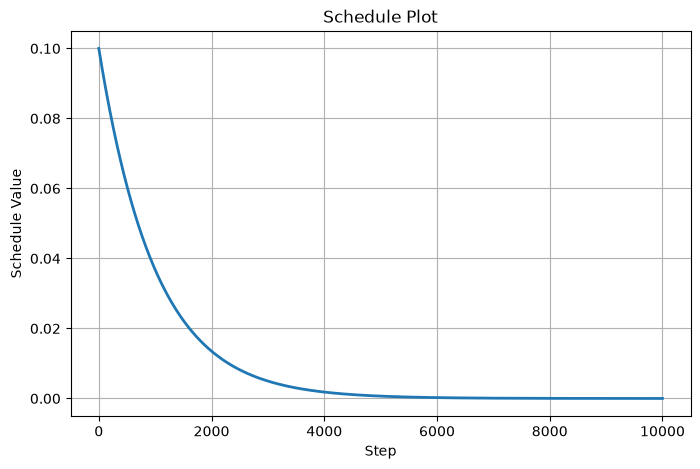

In [19]:
eps_schedule = ExponentialDecaySchedule(0.1, 0.00001, 0.999)
plot_schedule(eps_schedule, steps = 10000)

In [20]:
Q = Sarsa0_schedule(env, discount=1, alpha=.01, epsilon=eps_schedule, n=10000, rng=rng)

SARSA: 100%|██████████| 10000/10000 [00:06<00:00, 1587.38it/s]


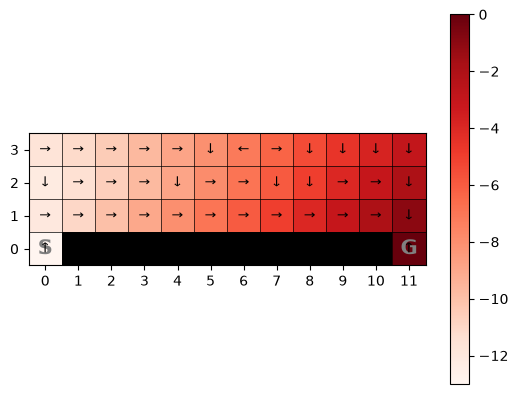

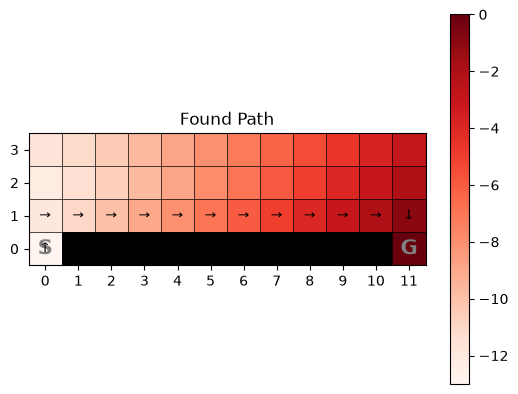

In [21]:
policy = np.argmax(Q, axis=1)
V = np.max(Q, axis = 1)
env.image(V, policy = policy)

path = sample_episode(env, policy=policy, max_len=100)
env.image(V=V, policy=policy, episode=path, title='Found Path')

### Performance of the Final Policy

We have extracted a deterministic greedy policy from the learned Q-function. Since the actions are also deterministic, we can sample a single episode
and calculate the return.

In [22]:
from gym_classics2.algorithms.monte_carlo_methods import sample_episode

episode = sample_episode(env, policy = policy)
display(episode)

discount = 1
rewards = np.array([sars[2] for sars in episode])
np.sum(rewards * np.power(discount, range(len(episode))))

[(0, np.int64(0), -1.0, 1),
 (1, np.int64(1), -1.0, 4),
 (4, np.int64(1), -1.0, 7),
 (7, np.int64(1), -1.0, 10),
 (10, np.int64(1), -1.0, 13),
 (13, np.int64(1), -1.0, 16),
 (16, np.int64(1), -1.0, 19),
 (19, np.int64(1), -1.0, 22),
 (22, np.int64(1), -1.0, 25),
 (25, np.int64(1), -1.0, 28),
 (28, np.int64(1), -1.0, 31),
 (31, np.int64(1), -1.0, 35),
 (35, np.int64(2), -1.0, 34)]

np.float64(-13.0)

The learned policy is optimal and takes 13 steps to get to the goal.

### Performance During Learning

We look at the return for each episode during the first 500 episodes of learning.

In [23]:
def Sarsa0_returns(env, discount, alpha, epsilon, n=100, rng=None):
    rng = np.random.default_rng(rng)
    # keep track of the returns
    Returns = [0] * n 
        
    Q = np.zeros((len(env.states()), len(env.actions())))
    
    for i in tqdm(range(n), desc="SARSA Returns"):
        s, r = env.reset()
 
          
        if rng.random() > epsilon(i):
            a = random_argmax(Q[s,:], rng)
        else:
            a = rng.integers(env.action_space.n)  
          
        t = 0
        done = False
        while not done:            
            sp, r, done, _, _ = env.step(a)
            Returns[i] += r * pow(discount, t)
            t += 1
            
            if rng.random() > epsilon(i):
                ap = random_argmax(Q[sp,:], rng)
            else:
                ap = rng.integers(env.action_space.n) 
        
            Q[s,a] = Q[s,a] + alpha * (r + discount * Q[sp,ap] - Q[s,a])    
            
            s = sp
            a = ap
          
    return Q, Returns

In [24]:
Q,returns = Sarsa0_returns(env, discount=1, alpha=0.01, epsilon=eps_schedule, n=10000, rng=rng)

SARSA Returns: 100%|██████████| 10000/10000 [00:07<00:00, 1357.00it/s]


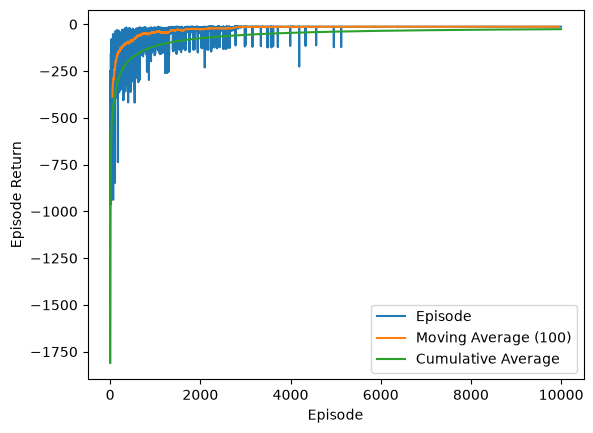

In [25]:
from gym_classics2.performance import plot_returns
plot_returns(returns)

We evaluate the $\epsilon$-greedy policy learned by Sarsa so we often get poor returns when an exploratory action is taken.
Once the schedule reduces $\epsilon$ close to 0, the final policy is evaluated. 

The learning rate $\alpha$ can also be reduced over time.
Choosing $\alpha$ and $\epsilon$ and the best schedules typically requires experimentation.  


&copy; 2025 [Michael Hahsler](https://michael.hahsler.net). 
This work is openly licensed under [Creative Commons Attribution-ShareAlike 4.0 International (CC BY-SA 4.0) License](https://creativecommons.org/licenses/by-sa/4.0/)

![CC BY-SA 4.0](https://licensebuttons.net/l/by-sa/3.0/88x31.png)